In [ ]:
# Installing dependencies
!pip install tensorflow keras matplotlib scikit-learn keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.4 MB/s eta 0:00:00


In [ ]:

dataset_path = 'Mazie_Dataset/data'

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

epochs = 10  # You can set to 20+ later if needed

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)

loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Found 3352 images belonging to 4 classes.
Found 836 images belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1154s 11s/step - accuracy: 0.3089 - loss: 1.4686 - val_accuracy: 0.3959 - val_loss: 1.3322
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 89s 707ms/step - accuracy: 0.3552 - loss: 1.3252 - val_accuracy: 0.4031 - val_loss: 1.2806
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 68s 651ms/step - accuracy: 0.3914 - loss: 1.2815 - val_accuracy: 0.3517 - val_loss: 1.2639
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 75s 712ms/step - accuracy: 0.4370 - loss: 1.2449 - val_accuracy: 0.5634 - val_loss: 1.1859
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 68s 653ms/step - accuracy: 0.4606 - loss: 1.2036 - val_accuracy: 0.4821 - val_loss: 1.1940
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 80s 638ms/step - accuracy: 0.4666 - loss: 1.1812 - val_accuracy: 0.5455 - val_loss: 1.1203
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 67s 639ms/step - accuracy: 0.4997 - loss: 1.1233 - val_accuracy: 0.5742 - val_loss: 1.1045
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 68s 646ms/step - accuracy: 0.4828 - loss: 1

27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 519ms/step - accuracy: 0.5355 - loss: 1.1899
Validation Accuracy: 61.00%


In [ ]:
#Training EfficientNetB0 with the with existing rsnet
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import mixed_precision
import os

# ✅ Enable mixed precision for T4 GPU
mixed_precision.set_global_policy('mixed_float16')

# 📂 Dataset and save path
data_dir = 'Mazie_Dataset/data'
model_path = 'CVProjectMaize/models/efficientnet_best.h5'
final_save_path = 'Mazie_Dataset/efficientNet.keras'

# ⚙️ Image config
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

# 🔄 Data Generators
datagen_train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    horizontal_flip=True
)

datagen_val = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen_train.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training'
)

val_gen = datagen_val.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation'
)

NUM_CLASSES = len(train_gen.class_indices)

# 🔁 Load previous EfficientNet model
print("\n🔁 Loading previous EfficientNetB0 model...")
eff_model = load_model(model_path)

# ✅ Unfreeze top layers for fine-tuning
for layer in eff_model.layers[-30:]:
    layer.trainable = True

# Recompile with lower learning rate
eff_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# 📍 Callbacks
eff_ckpt_path = '/content/efficientnet_best_finetuned.keras'
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3, verbose=1),
    ModelCheckpoint(eff_ckpt_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)
]

# 🔥 Train EfficientNetB0 (fine-tune)
eff_model.fit(
    train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks
)

# Evaluate and save
eff_model.load_weights(eff_ckpt_path)
_, eff_val_acc = eff_model.evaluate(val_gen, verbose=0)

print(f"\n🏁 Finished training EfficientNetB0. Final val_accuracy = {eff_val_acc:.2%}")
eff_model.save(final_save_path)
print(f"✅ Fine-tuned model saved to: {final_save_path}")


Found 3352 images belonging to 4 classes.
Found 836 images belonging to 4 classes.

🔁 Loading previous EfficientNetB0 model...


Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3860 - loss: 4.9309
Epoch 1: val_accuracy improved from -inf to 0.31220, saving model to /content/efficientnet_best_finetuned.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 1066s 10s/step - accuracy: 0.3867 - loss: 4.9074 - val_accuracy: 0.3122 - val_loss: 11.6595 - learning_rate: 1.0000e-05
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5834 - loss: 0.9848
Epoch 2: val_accuracy improved from 0.31220 to 0.31938, saving model to /content/efficientnet_best_finetuned.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 1025s 10s/step - accuracy: 0.5837 - loss: 0.9843 - val_accuracy: 0.3194 - val_loss: 8.4617 - learning_rate: 1.0000e-05
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6459 - loss: 0.8339
Epoch 3: val_accuracy improved from 0.31938 to 0.36842, saving model to /content/efficientnet_best_finetuned.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 1027s 10s/step - accuracy: 0.6462 - loss: 0.8334 - val_accuracy: 0.3684 - val

In [ ]:
#Traing MobileNetV2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

# ✅ Enable mixed precision for T4 GPU
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# 📂 Dataset and save path
data_dir = 'Mazie_Dataset/data'
model_save_path = 'Mazie_Dataset/maize_detection_model_best.keras'

# 🧼 Image Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

# 📦 Image Augmentation
datagen_train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    horizontal_flip=True
)

datagen_val = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen_train.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training'
)

val_gen = datagen_val.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation'
)

NUM_CLASSES = len(train_gen.class_indices)

# 🔧 Build MobileNetV2 model
def build_mobilenet():
    base = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    return Model(inputs, outputs)

print("\n📱 Training MobileNetV2 from scratch...")
mob_model = build_mobilenet()
mob_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_mob = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3, verbose=1),
    ModelCheckpoint(model_save_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)
]

# ⏱ Train MobileNetV2 and save to target path
mob_model.fit(
    train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks_mob
)

print(f"\n✅ MobileNetV2 model saved to: {model_save_path}")


Found 3352 images belonging to 4 classes.
Found 836 images belonging to 4 classes.

📱 Training MobileNetV2 from scratch...
Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7746 - loss: 0.6661
Epoch 1: val_accuracy improved from -inf to 0.89593, saving model to /content/drive/MyDrive/Mazie_Dataset/maize_detection_model_best.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 979s 9s/step - accuracy: 0.7751 - loss: 0.6649 - val_accuracy: 0.8959 - val_loss: 0.2384 - learning_rate: 0.0010
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8732 - loss: 0.3715
Epoch 2: val_accuracy improved from 0.89593 to 0.92584, saving model to /content/drive/MyDrive/Mazie_Dataset/maize_detection_model_best.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 968s 9s/step - accuracy: 0.8732 - loss: 0.3714 - val_accuracy: 0.9258 - val_loss: 0.1871 - learning_rate: 0.0010
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8853 - loss: 0.3190
Epoch 3: val_accuracy improved from 0.92584 to 0.92823, s

In [ ]:
#Calculating Accuracy
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 🔁 Recreate validation generator
data_dir = 'Mazie_Dataset/data'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen_val = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = datagen_val.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ✅ Load MobileNetV2 model
model = load_model('CVProjectMaize/models/maize_detection_model_best.keras')

# 🧪 Evaluate and print accuracy
loss, acc = model.evaluate(val_gen, verbose=1)
print(f"\n📊 MobileNetV2 Validation Accuracy: {acc:.2%}")


Found 836 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 629s 24s/step - accuracy: 0.9322 - loss: 0.1947

📊 MobileNetV2 Validation Accuracy: 94.74%


Found 836 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 70 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 297s 11s/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step


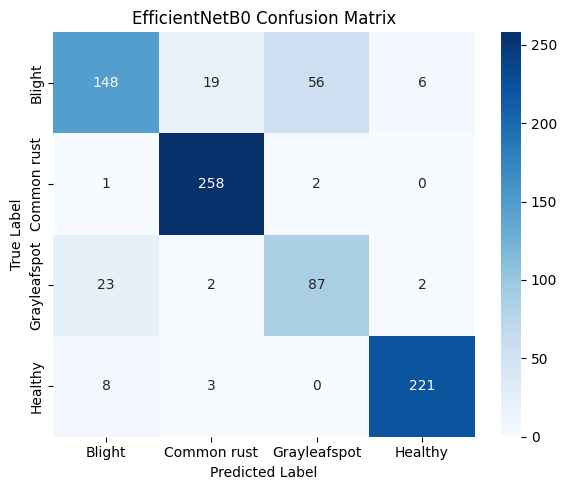

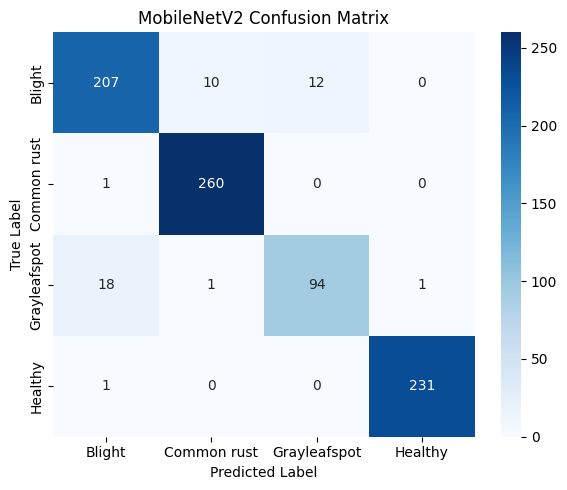

🔍 EfficientNetB0 Classification Report:

              precision    recall  f1-score   support

      Blight       0.82      0.65      0.72       229
 Common rust       0.91      0.99      0.95       261
Grayleafspot       0.60      0.76      0.67       114
     Healthy       0.97      0.95      0.96       232

    accuracy                           0.85       836
   macro avg       0.83      0.84      0.83       836
weighted avg       0.86      0.85      0.85       836

🔍 MobileNetV2 Classification Report:

              precision    recall  f1-score   support

      Blight       0.91      0.90      0.91       229
 Common rust       0.96      1.00      0.98       261
Grayleafspot       0.89      0.82      0.85       114
     Healthy       1.00      1.00      1.00       232

    accuracy                           0.95       836
   macro avg       0.94      0.93      0.93       836
weighted avg       0.95      0.95      0.95       836



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset and class labels
data_dir = 'Mazie_Dataset/data'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
class_labels = ['Blight', 'Common rust', 'Grayleafspot', 'Healthy']

# Load validation generator
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

y_true = val_gen.classes

# Load models
model_eff = load_model('CVProjectMaize/models/efficientNet.keras')
model_mob = load_model('CVProjectMaize/models/maize_detection_model_best.keras')

# Predict labels
y_pred_eff = model_eff.predict(val_gen)
y_pred_eff_classes = np.argmax(y_pred_eff, axis=1)

y_pred_mob = model_mob.predict(val_gen)
y_pred_mob_classes = np.argmax(y_pred_mob, axis=1)

# Function to plot confusion matrix
def plot_confusion(cm, labels, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Confusion matrices
cm_eff = confusion_matrix(y_true, y_pred_eff_classes)
cm_mob = confusion_matrix(y_true, y_pred_mob_classes)

# Plot both
plot_confusion(cm_eff, class_labels, "EfficientNetB0 Confusion Matrix")
plot_confusion(cm_mob, class_labels, "MobileNetV2 Confusion Matrix")

# Optional: Classification report
print("🔍 EfficientNetB0 Classification Report:\n")
print(classification_report(y_true, y_pred_eff_classes, target_names=class_labels))

print("🔍 MobileNetV2 Classification Report:\n")
print(classification_report(y_true, y_pred_mob_classes, target_names=class_labels))


Saving Screenshot 2025-05-01 083213.png to Screenshot 2025-05-01 083213.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


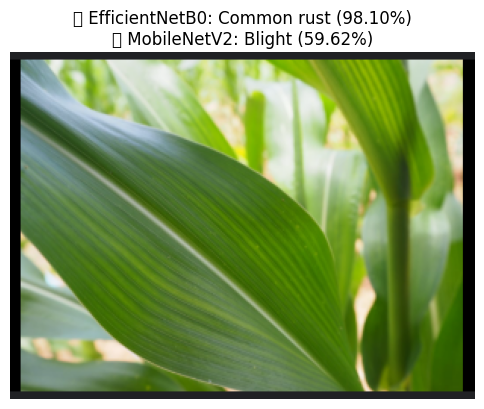

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image
import os

# ✅ Load both models
efficientnet_model = load_model('CVProjectMaize/models/efficientNet.keras')
mobilenet_model = load_model('CVProjectMaize/models/maize_detection_model_best.keras')

# ✅ Class labels (make sure they match your training generator order)
class_labels = ['Blight', 'Common rust', 'Grayleafspot', 'Healthy']

# 📥 Upload an image
from google.colab import files
uploaded = files.upload()

# 📐 Preprocess uploaded image
IMG_SIZE = (224, 224)

for file_name in uploaded.keys():
    img_path = file_name
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize(IMG_SIZE)

    img_array = image.img_to_array(img_resized) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)  # shape: (1, 224, 224, 3)

    # 🔮 Predict using both models
    pred_eff = efficientnet_model.predict(img_batch)[0]
    pred_mob = mobilenet_model.predict(img_batch)[0]

    label_eff = class_labels[np.argmax(pred_eff)]
    label_mob = class_labels[np.argmax(pred_mob)]

    conf_eff = np.max(pred_eff) * 100
    conf_mob = np.max(pred_mob) * 100

    # 🖼️ Display
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("🟩 EfficientNetB0: {} ({:.2f}%)\n🟦 MobileNetV2: {} ({:.2f}%)".format(
        label_eff, conf_eff, label_mob, conf_mob
    ))
    plt.show()
